# Figure 5: Detailed power plant projections in 2055 in the Denver, Colorado area

**NOTE:** To run this notebook, the `prepare_data.ipynb` must first be run and all prerequisite data must be downloaded.

### Imports

In [1]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, ConnectionPatch
import geopandas as gpd
from shapely.geometry import box
import numpy as np
import pandas as pd
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter
from shapely.geometry import box
import os
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patheffects as path_effects

### Paths

In [2]:
data_dir = os.path.join(os.path.dirname(os.getcwd()), 'data')
fig_dir = os.path.join(os.path.dirname(os.getcwd()), 'figures')

plant_fn = os.path.join(data_dir, 'power_plants_by_sited_year.geojson')
clustered_plant_fn = os.path.join(data_dir, 'clustered_power_plants_2055.geojson')
state_fn = os.path.join(data_dir, 'cb_2024_us_state_500k/cb_2024_us_state_500k.shp')
north_america_fn = os.path.join(data_dir, 'PoliticalBoundaries_Shapefile/NA_PoliticalDivisions/data/bound_p/boundaries_p_2021_v3.shp')
bathymetry_fn = os.path.join(data_dir, 'bathymetry_basemap.geojson')
transmission_fn = os.path.join(data_dir, 'US_Electric_Power_Transmission_Lines_5037807202786552385.geojson')
urban_shp_fn = os.path.join(data_dir, 'cb_2018_us_ua10_500k', 'cb_2018_us_ua10_500k.shp')

### Settings

In [3]:
color_dict = {
                'Geothermal':'#ad1b0a',
                'Solar':'#F7B615', 
                'Wind':'#95C060',
                'Wind (Offshore)': 'teal',
                'Biomass':'#e30787', 
                'Hydroelectric':'#2B7F9E', 
                'Nuclear': '#813f99', 
                'Petroleum':'#d9c7a9', 
                'Natural Gas':'#8860a6',
                'Coal':'#363636',
}

In [4]:
# read in siting data
gdf = gpd.read_file(plant_fn)
data = gpd.read_file(clustered_plant_fn)

# state shapefile
state = gpd.read_file(state_fn).to_crs('ESRI:102003')

#urban area shapefile
urban_shp = gpd.read_file(urban_shp_fn).to_crs('ESRI:102003')
co_urban_shp = gpd.clip(urban_shp,state[state.STUSPS=='CO'])

# wecc states
wecc_states = ['CA', 'OR', 'WA', 'MT', 'ID', 'WY', 'UT', 'NV', 'AZ', 'NM', 'CO']
wecc = state[state.STUSPS.isin(wecc_states)].copy()
wecc_dissolved = wecc.dissolve().envelope.buffer(100000, join_style='mitre')
xMin, yMin, xMax, yMax = wecc.dissolve().envelope.buffer(100000, join_style='mitre').total_bounds

# north america
na_shape = gpd.read_file(north_america_fn).to_crs('ESRI:102003')
na_shape = na_shape[na_shape.COUNTRY.isin(['MEX', 'CAN'])]
na_shape = na_shape.dissolve()
na_shape2 = gpd.clip(na_shape,  wecc.dissolve().envelope.buffer(100000, join_style='mitre'))

# transmission
transmission = gpd.read_file(transmission_fn)
transmission = gpd.clip(transmission, wecc.to_crs(transmission.crs))
transmission = transmission.to_crs('ESRI:102003')
transmission_230 = transmission[transmission.VOLTAGE >= 230].copy()
transmission_230 = gpd.clip(transmission_230, wecc)

# bathymetry shapefile
basemap = gpd.read_file(bathymetry_fn)
basemap_wecc = gpd.clip(basemap, wecc_dissolved)

# city coordinates
city_data = {'city': ['Denver', 'Boulder', 'Colorado\n Springs'], 
        'Latitude': [39.7392358, 40.0149856, 38.8338816],                 
        'Longitude': [-104.990251, -105.2705456, -104.8213634]}

city_df = pd.DataFrame.from_dict(city_data)
city_gdf = gpd.GeoDataFrame(
    city_df, geometry=gpd.points_from_xy(city_df.Longitude, city_df.Latitude), crs="EPSG:4326"
)
city_gdf.to_crs('ESRI:102003', inplace=True)

In [5]:
# line legend
transmission_legend = Line2D([0], [0], color='black', lw=1, linestyle='dashed', label='Transmission Lines ≥230kv')
urban_boundary = mpatches.Patch(facecolor='grey', alpha = .3, label='Urban Area', edgecolor='grey', lw=.75)
state_boundary = Line2D([0], [0], color='black', lw=1, label='US State Boundaries')

boundary_legend_elements = [ transmission_legend, state_boundary, urban_boundary ]

timestep = 2055 

# color legend
legend_elements = []
for tech in ['Solar', 'Wind', 'Natural Gas', 'Hydroelectric']:
    if tech in gdf[(gdf.sited_year <= timestep) & (gdf.retirement_year > timestep)].generation_type.unique():
        tech_patch = mpatches.Patch(facecolor=color_dict[tech], label=tech, edgecolor='black', lw=.75)
        legend_elements.append(tech_patch)

## ccs legend
non_ccs = Line2D([0], [0], lw=0, label='Without CCS', marker='o', markersize = 8, markerfacecolor='white', markeredgecolor='black')
legend_elements.append(non_ccs)
ccs = Line2D([0], [0], lw=0, label='With CCS', marker='D', markersize = 8, markerfacecolor='white', markeredgecolor='black')
legend_elements.append(ccs)

In [6]:
data['color'] = np.where(data.tech_simple.str.contains('Gas'), color_dict['Natural Gas'], data['color'] )

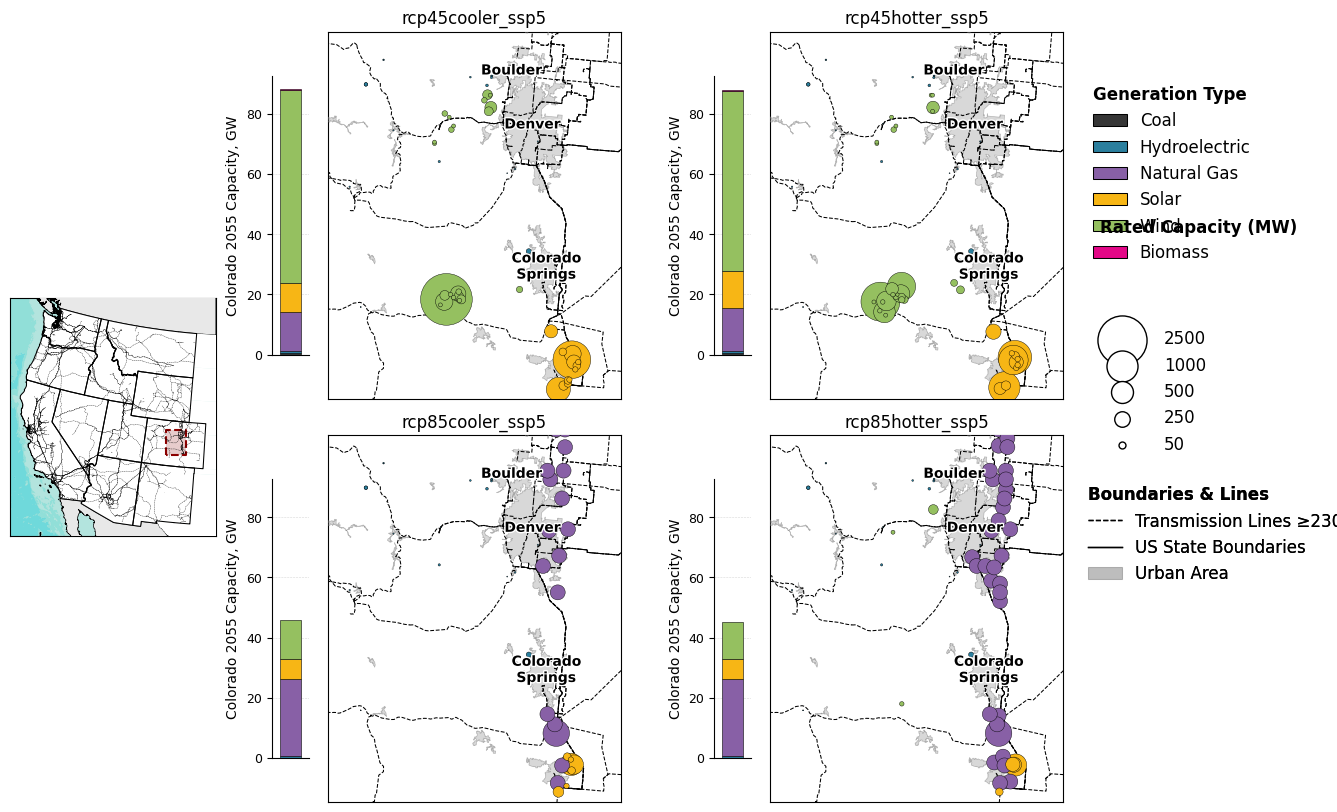

In [39]:
my_scale = 2
xmin = -.9e6
xmax = -.7e6
ymin = .1e6
ymax = .35e6

# Create a Shapely Polygon object from the bounding box
polygon_geometry = box(xmin, ymin, xmax, ymax)
polygon_gs = gpd.GeoSeries([polygon_geometry], crs="ESRI:102003")
polygon_gdf = gpd.GeoDataFrame(geometry=polygon_gs)

plot_scenario_list = [
    'rcp45cooler_ssp5',
    'rcp45hotter_ssp5',
    'rcp85cooler_ssp5',
    'rcp85hotter_ssp5',
]

bar_data = pd.read_csv(os.path.join(data_dir, 'operational_power_plants_by_timestep.csv'))
bar_data = bar_data[
    (bar_data.region_name == 'colorado')
    & (bar_data.timestep == 2055)
    & (bar_data.scenario.isin(plot_scenario_list))
]

stack_order = ['Coal', 'Hydroelectric', 'Natural Gas', 'Solar', 'Wind', 'Biomass']
bar_plot_data = (
    bar_data.pivot_table(
        index='scenario',
        columns='generation_type',
        values='unit_size_mw',
        aggfunc='sum',
        fill_value=0,
    )
    .reindex(plot_scenario_list)
    .reindex(columns=stack_order, fill_value=0)
)
bar_ymax = bar_plot_data.sum(axis=1).max()
bar_ymax = bar_ymax * 1.05 if bar_ymax > 0 else 1

legend_elements = []
for tech in stack_order:
    if ((bar_plot_data[tech] > 0).any()) or (tech in gdf[(gdf.sited_year <= 2055) & (gdf.retirement_year > 2055)].generation_type.unique()):
        tech_patch = mpatches.Patch(facecolor=color_dict[tech], label=tech, edgecolor='black', lw=.75)
        legend_elements.append(tech_patch)

gdf_colorado = data[data.region_name == 'colorado'].copy()
gdfs_no_ccs = []
gdfs_ccs = []
for scenario in plot_scenario_list:
    gdf_plot = gdf_colorado[gdf_colorado.scenario == scenario].copy()
    gdf_plot = gdf_plot.sort_values(by='unit_size_mw', ascending=False)
    gdf_plot_ccs = gdf_plot[gdf_plot.tech_simple.str.contains('CCS')].copy()
    gdf_plot = gdf_plot[~gdf_plot.tech_simple.str.contains('CCS')].copy()
    gdfs_no_ccs.append(gdf_plot)
    gdfs_ccs.append(gdf_plot_ccs)

fig = plt.figure(figsize=(17, 10))

# 2 rows x 3 columns layout with companion bar charts beside each zoom panel
gs = gridspec.GridSpec(
    2, 3,
    width_ratios=[.5, 2.1, 0.6],
    height_ratios=[1, 1],
    figure=fig,
    wspace=0.0, hspace=0
)

# Main map (left, spans both rows)
ax_map = fig.add_subplot(gs[:, 0])

gs_right = gridspec.GridSpecFromSubplotSpec(
    2, 4, subplot_spec=gs[:, 1], width_ratios=[0.25, 1.1, 0.25, 1.1], wspace=0.1, hspace=0.1
)

bar11 = fig.add_subplot(gs_right[0, 0])
ax11 = fig.add_subplot(gs_right[0, 1])
bar12 = fig.add_subplot(gs_right[0, 2])
ax12 = fig.add_subplot(gs_right[0, 3])
bar21 = fig.add_subplot(gs_right[1, 0])
ax21 = fig.add_subplot(gs_right[1, 1])
bar22 = fig.add_subplot(gs_right[1, 2])
ax22 = fig.add_subplot(gs_right[1, 3])

legend_ax = fig.add_subplot(gs[:, 2])

polygon_gdf.boundary.plot(ax=ax_map, color='darkred', linestyle='dashed', alpha=1, zorder=10)
polygon_gdf.plot(ax=ax_map, color='darkred', alpha=.2, zorder=10)

wecc.boundary.plot(ax=ax_map, color='black', lw=.75, zorder=8)
state.plot(ax=ax_map, color='white', alpha=1, zorder=7)
wecc.plot(ax=ax_map, color='white', lw=.75, zorder=6)
transmission_230.plot(ax=ax_map, lw=.25, color='black', linestyle='dashed', zorder=11)
na_shape2.plot(ax=ax_map, color='#e8e8e8', alpha=1, zorder=3)
na_shape2.boundary.plot(ax=ax_map, color='black', zorder=4, lw=.5)
basemap_wecc.plot(ax=ax_map, color=basemap_wecc.color, zorder=1)
ax_map.set_xlim(xMin, xMax)
ax_map.set_ylim(yMin, yMax)

ax_map.tick_params(axis='both', which='both', length=0, labelbottom=False, labelleft=False)
for s in ['top', 'right', 'bottom', 'left']:
    ax_map.spines[s].set_visible(True)
ax_map.set_facecolor('#b3e4de')

bar_axes = [bar11, bar12, bar21, bar22]
ax_list = [ax11, ax12, ax21, ax22]

for i in range(4):
    bar_bottom = 0
    scenario_bar = bar_plot_data.loc[plot_scenario_list[i]]
    for tech in stack_order:
        height = scenario_bar[tech]
        if height <= 0:
            continue
        bar_axes[i].bar(
            0,
            height,
            bottom=bar_bottom,
            color=color_dict[tech],
            edgecolor='black',
            linewidth=.4,
            width=.5,
        )
        bar_bottom += height

    bar_axes[i].set_ylim(0, bar_ymax)
    bar_axes[i].set_xlim(-0.45, 0.45)
    bar_axes[i].set_xticks([])
    bar_axes[i].grid(True, axis='y', linestyle='--', linewidth=0.4, alpha=0.5)
    bar_axes[i].set_axisbelow(True)
    bar_axes[i].yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value / 1000:.0f}"))
    bar_axes[i].spines['top'].set_visible(False)
    bar_axes[i].spines['right'].set_visible(False)
    if i in [0, 1, 2, 3]:
        bar_axes[i].set_ylabel('Colorado 2055 Capacity, GW', fontsize=10)
        bar_axes[i].tick_params(axis='y', labelsize=9)
    else:
        bar_axes[i].set_yticklabels([])
        bar_axes[i].tick_params(axis='y', length=0)

    pos = bar_axes[i].get_position()
    bar_axes[i].set_position([
        pos.x0 + pos.width * 0.75,
        pos.y0 + pos.height * 0.12,
        pos.width * 0.5,
        pos.height * 0.76,
    ])

    gdfs_no_ccs[i].plot(
        ax=ax_list[i],
        marker='o',
        lw=.3,
        facecolor=gdfs_no_ccs[i]['color'],
        edgecolor='black',
        markersize=gdfs_no_ccs[i]['unit_size_mw'] / my_scale,
        zorder=35,
    )
    if not gdfs_ccs[i].empty:
        gdfs_ccs[i].plot(
            ax=ax_list[i],
            marker='D',
            lw=.3,
            facecolor=gdfs_ccs[i]['color'],
            edgecolor='black',
            markersize=gdfs_ccs[i]['unit_size_mw'] / my_scale,
            zorder=35,
        )

    for x, y, label in zip(city_gdf.geometry.x, city_gdf.geometry.y, city_gdf.city):
        if label == 'Boulder':
            ax_list[i].annotate(
                label,
                xy=(x, y),
                xytext=(-13, 1),
                textcoords='offset points',
                size=10,
                zorder=37,
                weight='bold',
                path_effects=[path_effects.withStroke(linewidth=2, foreground='white')],
            )
        else:
            ax_list[i].annotate(
                label,
                xy=(x, y),
                xytext=(-18, -3),
                textcoords='offset points',
                size=10,
                zorder=37,
                weight='bold',
                path_effects=[path_effects.withStroke(linewidth=2, foreground='white')],
            )

    transmission_230.plot(ax=ax_list[i], lw=.75, color='black', linestyle='dashed', zorder=31)
    co_urban_shp.boundary.plot(ax=ax_list[i], color='grey', alpha=.5, lw=.5, zorder=30)
    co_urban_shp.plot(ax=ax_list[i], color='grey', alpha=.3, zorder=30)

    ax_list[i].set_xlim(xmin, xmax)
    ax_list[i].set_ylim(ymin, ymax)
    ax_list[i].tick_params(axis='both', which='both', length=0, labelbottom=False, labelleft=False)
    ax_list[i].spines['top'].set_visible(True)
    ax_list[i].spines['right'].set_visible(True)
    ax_list[i].spines['bottom'].set_visible(True)
    ax_list[i].spines['left'].set_visible(True)
    ax_list[i].set_title(plot_scenario_list[i])

# generation type legend
legend1 = legend_ax.legend(handles=legend_elements, title='Generation Type', 
                           title_fontproperties={'weight':'bold', 'size':12, }, 
                              bbox_to_anchor=(.75, .95), frameon=False, alignment='left',fontsize=12)
legend_ax.add_artist(legend1)

# capacity scale legend
for area in sorted([50/my_scale, 250/my_scale, 500/my_scale, 1000/my_scale,2500/my_scale], reverse=True):
    legend_ax.scatter([], [], c='white', s=area, label=str(int(area*my_scale)),edgecolors='black')
  
legend2 = legend_ax.legend(frameon=False, labelspacing=.5, title='Rated Capacity (MW)',
                           title_fontproperties={'weight':'bold', 'size':12}, 
                           handletextpad=1.5,
                        bbox_to_anchor=(.5, .55), loc="center", alignment='left', fontsize=12)
legend2.get_title().set_position((-5, 85))
legend_ax.add_artist(legend2)

# boundary legend
legend3 = legend_ax.legend(handles=boundary_legend_elements, title='Boundaries & Lines', 
                                title_fontproperties={'weight':'bold', 'size':12}, 
                              alignment='left',bbox_to_anchor=(1.2, .43), frameon=False, fontsize=12)

legend_ax.add_artist(legend3)
legend_ax.set_axis_off()

plt.savefig(os.path.join(fig_dir, 'fig5.png'), dpi=400, bbox_inches='tight')

plt.show()